# Gathering Average Distances Traveled in Glacier Bay
Verifying Accuracy and Demonstrating Functionality

_Graham Brady_
## Use AIS data to collect data about each cruise ship that entered Glacier Bay National Park (GLBA) in 2023
 With _Shippy_, a python toolset, I linked several existing libraries within custom workflows to analyze AIS data for solutions to our research questions. Each cruise ship's path through the time series was divided into segments based on being in **Port** or **Transit**. These status were calculated using geofences and attributes within the AIS data.


First, import the libraries and run the constructor on the data folder.

In [1]:
from app import App
from BoatsData import BoatsData
from BoatData import BoatData
from Cruise import Cruise
from Geoprocessor import Geoprocessor
from PortManager import PortManager
from PathCalculations import PathCalculations
from Mapper import Mapper
from Statistics import Statistics

import matplotlib.pyplot as plt
import pandas as pd
from geopy.distance import geodesic
from geopy.distance import distance

from shapely.geometry import LineString
import geopandas as gpd

import pandas as pd
import os
import geopandas as gpd


# Load data from main dir of data folders
a = App(r'./data/ais_data')

created new cruise for this: NORWEGIAN BLISS_01
created new cruise for this: NORWEGIAN BLISS_02
created new cruise for this: NORWEGIAN JEWEL_01
created new cruise for this: EURODAM_01
created new cruise for this: NORWEGIAN BLISS_03
created new cruise for this: NIEUW AMSTERDAM_01
created new cruise for this: GRAND PRINCESS_01
created new cruise for this: KONINGSDAM_01
created new cruise for this: NORWEGIAN JEWEL_02
created new cruise for this: NORWEGIAN SPIRIT_01
created new cruise for this: CROWN PRINCESS_01
created new cruise for this: EURODAM_02
created new cruise for this: GRAND PRINCESS_02
created new cruise for this: KONINGSDAM_02
created new cruise for this: NORWEGIAN BLISS_04
created new cruise for this: NOORDAM_01
created new cruise for this: NORWEGIAN ENCORE_01
created new cruise for this: RUBY PRINCESS_01
created new cruise for this: NIEUW AMSTERDAM_02
created new cruise for this: NORWEGIAN SPIRIT_02
created new cruise for this: VOLENDAM_01
created new cruise for this: NORWEG

/Users/Graham/cruise/BoatsData.py:212: FutureWarning: merging between different levels is deprecated and will be removed in a future version. (2 levels on the left, 1 on the right)
  transits_stats = pd.merge(transits_stats, unique_segment_ids, on=['from_port', 'to_port'])


#### **Section 1**: View the data.

To view the data frame associated with our calculations, we can show the full contents using a flattening method. Keep in mind, this full df does not additionaly provide information about ports, just represent the raw large format of the data input:


In [5]:
flattened_df = a.getFlattenedAISData('2023_ais')
flattened_df

,lat,lon,bs_ts,geometry,mmsi,callsign,imo,name,nav_status,cog,sog,destination,eta,shiptype,draught,length,width,cruise_id,Unnamed: 0
0,54.065173,-133.716653,2023-04-16 23:49:36-08:00,POINT (-133.71665 54.06517),311000710,C6DL4,9751509,NORWEGIAN BLISS,Under way using engine,342.5,21.9,"SKAGWAY, USA",2023-04-18 15:00:00,Passenger ship,8.5,334.0,45.0,NORWEGIAN BLISS_01,NaN
1,54.094087,-133.732508,2023-04-16 23:54:36-08:00,POINT (-133.73251 54.09409),311000710,C6DL4,9751509,NORWEGIAN BLISS,Under way using engine,341.2,22.2,"SKAGWAY, USA",2023-04-18 15:00:00,Passenger ship,8.5,334.0,45.0,NORWEGIAN BLISS_01,NaN
2,54.102338,-133.736868,2023-04-16 23:56:00-08:00,POINT (-133.73687 54.10234),311000710,C6DL4,9751509,NORWEGIAN BLISS,Under way using engine,344.3,22.3,"SKAGWAY, USA",2023-04-18 15:00:00,Passenger ship,8.5,334.0,45.0,NORWEGIAN BLISS_01,NaN
3,54.110723,-133.740657,2023-04-16 23:57:24-08:00,POINT (-133.74066 54.11072),311000710,C6DL4,9751509,NORWEGIAN BLISS,Under way using engine,348.2,22.1,"SKAGWAY, USA",2023-04-18 15:00:00,Passenger ship,8.5,334.0,45.0,NORWEGIAN BLISS_01,NaN
4,54.120417,-133.744378,2023-04-16 23:59:00-08:00,POINT (-133.74438 54.12042),311000710,C6DL4,9751509,NORWEGIAN BLISS,Under way using engine,346.1,22.4,"SKAGWAY, USA",2023-04-18 15:00:00,Passenger ship,8.5,334.0,45.0,NORWEGIAN BLISS_01,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1207701,48.070883,-125.764715,2023-08-18 05:38:43-08:00,POINT (-125.76472 48.07088),310625000,ZCEF2,9477438,QUEEN ELIZABETH,Under way using engine,176.9,17.6,"SAN FRANCISCO, US",2023-08-20 09:15:00,Passenger ship,8.1,294.0,36.0,QUEEN ELIZABETH_01,1711.0
1207702,48.070395,-125.764740,2023-08-18 05:38:51-08:00,POINT (-125.76474 48.0704),310625000,ZCEF2,9477438,QUEEN ELIZABETH,Under way using engine,180.3,17.7,"SAN FRANCISCO, US",2023-08-20 09:15:00,Passenger ship,8.1,294.0,36.0,QUEEN ELIZABETH_01,1712.0
1207703,48.069987,-125.764712,2023-08-18 05:38:55-08:00,POINT (-125.76471 48.06999),310625000,ZCEF2,9477438,QUEEN ELIZABETH,Under way using engine,177.6,17.6,"SAN FRANCISCO, US",2023-08-20 09:15:00,Passenger ship,8.1,294.0,36.0,QUEEN ELIZABETH_01,1713.0
1207704,48.068927,-125.764708,2023-08-18 05:39:09-08:00,POINT (-125.76471 48.06893),310625000,ZCEF2,9477438,QUEEN ELIZABETH,Under way using engine,180.4,17.7,"SAN FRANCISCO, US",2023-08-20 09:15:00,Passenger ship,8.1,294.0,36.0,QUEEN ELIZABETH_01,1714.0


#### **Section 2**: Asserting we have the proper results describing entries to Glacier Bay.
 

In [6]:
# Revision and affirmation of values
within_glba = a.data_dict['2023_ais']['ais_data']['within_glba']
assert within_glba.segment_id.nunique() == 258 # will fail if false
print(within_glba.segment_id.nunique())

258


Similarly, wrangle another data product to show the same result as above.

In [7]:
inPorts = a.data_dict['2023_ais']['sampled_routes']['ports']
glba_visits = inPorts[inPorts.port == 'Glacier Bay']
del glba_visits['level_0']
del glba_visits['index']
assert len(glba_visits) == 258 # will fail if false
glba_visits

,segment_id,port,start_index,end_index,port_duration,timelapse,time_in,time_out,distance_nm,imo,name
37,CROWN_PRINCESS_0076,Glacier Bay,23649,24026,10.802222,10.802,2023-07-09 05:45:35-08:00,2023-07-09 16:33:43-08:00,122.18,9293399.0,CROWN PRINCESS
83,EURODAM_0004,Glacier Bay,752,1029,9.213056,9.213,2023-05-02 06:18:47-08:00,2023-05-02 15:31:34-08:00,114.68,9378448.0,EURODAM
88,EURODAM_0014,Glacier Bay,3278,3606,9.716667,9.717,2023-05-09 06:17:11-08:00,2023-05-09 16:00:11-08:00,120.05,9378448.0,EURODAM
93,EURODAM_0024,Glacier Bay,5957,6291,9.445556,9.446,2023-05-16 06:17:59-08:00,2023-05-16 15:44:43-08:00,122.12,9378448.0,EURODAM
98,EURODAM_0034,Glacier Bay,8618,8905,9.600000,9.600,2023-05-23 06:16:15-08:00,2023-05-23 15:52:15-08:00,121.49,9378448.0,EURODAM
...,...,...,...,...,...,...,...,...,...,...,...
1981,VOLENDAM_0126,Glacier Bay,37383,37692,9.058056,9.058,2023-08-27 05:52:43-08:00,2023-08-27 14:56:12-08:00,119.16,9156515.0,VOLENDAM
1985,VOLENDAM_0134,Glacier Bay,40055,40367,9.065556,9.066,2023-09-03 06:01:39-08:00,2023-09-03 15:05:35-08:00,120.79,9156515.0,VOLENDAM
1989,VOLENDAM_0142,Glacier Bay,42493,42812,8.847500,8.848,2023-09-10 06:22:48-08:00,2023-09-10 15:13:39-08:00,120.21,9156515.0,VOLENDAM
1993,VOLENDAM_0150,Glacier Bay,45106,45430,8.861389,8.861,2023-09-17 06:29:00-08:00,2023-09-17 15:20:41-08:00,114.08,9156515.0,VOLENDAM


Gather the rounded statistics from the **Glacier Bay Visit Table**

In [8]:
import pandas as pd

# Assuming your DataFrame is named df
# Calculate mean and standard deviation for the 'distance' field
mean_distance = round(glba_visits['distance_nm'].mean(), 3)
std_distance = round(glba_visits['distance_nm'].std(), 3)

# Calculate mean and standard deviation for the 'timelapse' field
mean_timelapse = round(glba_visits['timelapse'].mean(), 3)
std_timelapse = round(glba_visits['timelapse'].std() ,3)

# Output the results
print(f"Mean Distance: {mean_distance}, Standard Deviation: {std_distance}")
print(f"Mean Timelapse: {mean_timelapse}, Standard Deviation: {std_timelapse}")

Mean Distance: 117.604, Standard Deviation: 4.948
Mean Timelapse: 9.646, Standard Deviation: 0.717


#### **Section 3**: Verify the contents of shapefiles.

Because the main processing flow of the data relies on geometries of docks and Glacier Bay, let's take note of the files being used as dock geofences.

In [9]:
dock = gpd.read_file(r"./data/buffers/docks_buffered_edited_gb.shp")
track = gpd.read_file(r"./main_products/boatData/2023_ais_boatDataLineShapefile.shp")
alaska = BoatsData.ALASKA_COASTLINE_ALBERS


track = track.to_crs(dock.crs)
dock

,name,geometry
0,Juneau,"POLYGON ((1129916.274 1089943.448, 1129906.644..."
1,Skagway,"POLYGON ((1043297.859 1198128.192, 1043288.228..."
2,Seward,"POLYGON ((254720.021 1134896.733, 254710.39 11..."
3,Haines,"POLYGON ((1043623.995 1173300.461, 1043614.365..."
4,Whittier,"POLYGON ((290312.693 1210202.597, 290303.062 1..."
5,Anchorage,"POLYGON ((221349.579 1255301.54, 221339.949 12..."
6,Kodiak,"POLYGON ((96458.123 866399.073, 96448.492 8662..."
7,Petersburg,"POLYGON ((1263341.505 957673.759, 1263331.874 ..."
8,Wrangell,"POLYGON ((1308817.477 932629.306, 1308807.846 ..."
9,Prince Rupert,"POLYGON ((1512077.637 750008.375, 1512068.007 ..."


Display the unique ships represented in the AIS data, from which LineStrings of their tracks during the 2023 season were gathered.

In [10]:
track

,boatName,startDate,endDate,geometry
0,NORWEGIAN BLISS,2023-04-16,2023-10-26,"LINESTRING (1309198.855 651618.313, 1307241.75..."
1,NORWEGIAN JEWEL,2023-04-28,2023-10-08,"LINESTRING (1475869.271 711133.676, 1474483.53..."
2,EURODAM,2023-04-30,2023-10-05,"LINESTRING (1306928.953 651545.042, 1305361.25..."
3,NIEUW AMSTERDAM,2023-05-01,2023-09-29,"LINESTRING (1476256.411 711350.503, 1474843.81..."
4,GRAND PRINCESS,2023-05-02,2023-09-22,"LINESTRING (1311177.688 652325.691, 1310166.64..."
5,KONINGSDAM,2023-05-03,2023-10-06,"LINESTRING (1477719.674 711522.267, 1476585.29..."
6,NORWEGIAN SPIRIT,2023-05-03,2023-09-06,"LINESTRING (978527.356 848157.024, 978739.515 ..."
7,CROWN PRINCESS,2023-05-06,2023-09-28,"LINESTRING (1311473.339 650584.85, 1309762.586..."
8,NOORDAM,2023-05-08,2023-09-29,"LINESTRING (1303740.598 649205.624, 1301637.47..."
9,NORWEGIAN ENCORE,2023-05-08,2023-10-27,"LINESTRING (1311928.894 651804.294, 1310021.22..."


#### **Section 4**: Plot vicinity maps for each dock.

Produce images showing the dock geofences of the ports. These are small png outputs of vicinity maps based on maximum extent of each dock feature overlain with cruise tracks and the Alaska coastline. These files are located in `./maps/docks` and are also available for view in GIS software through

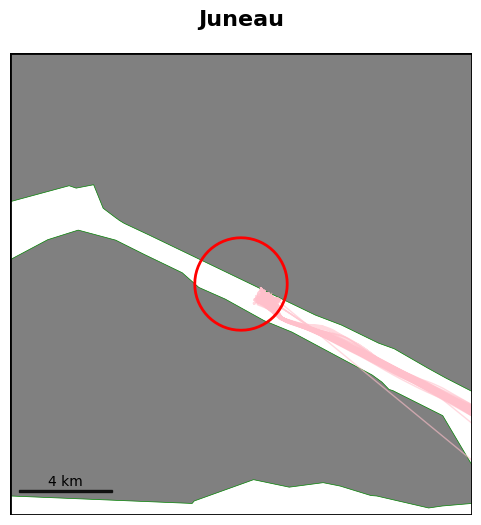

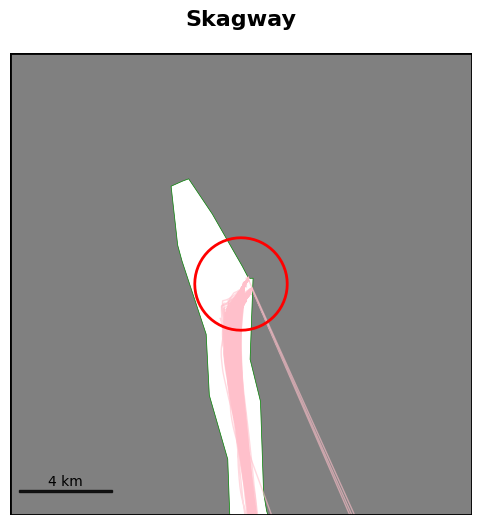

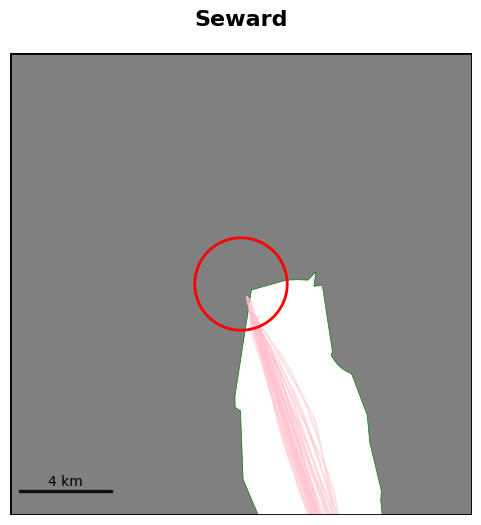

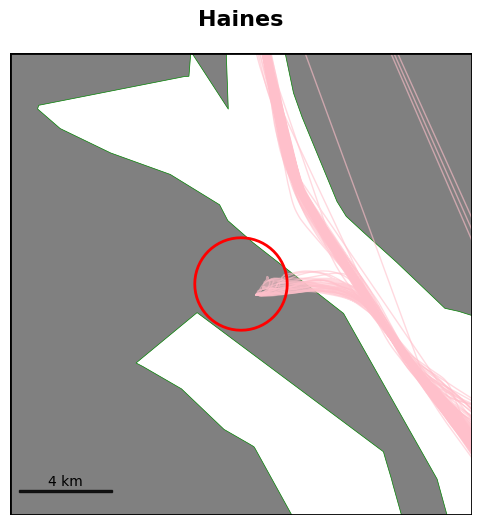

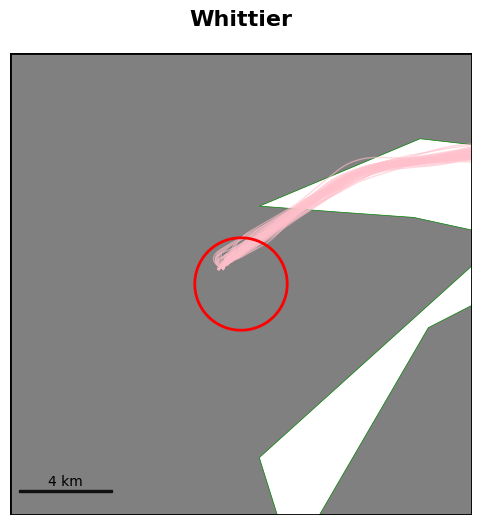

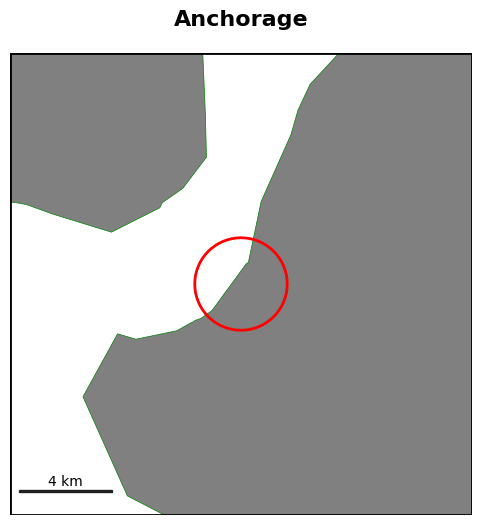

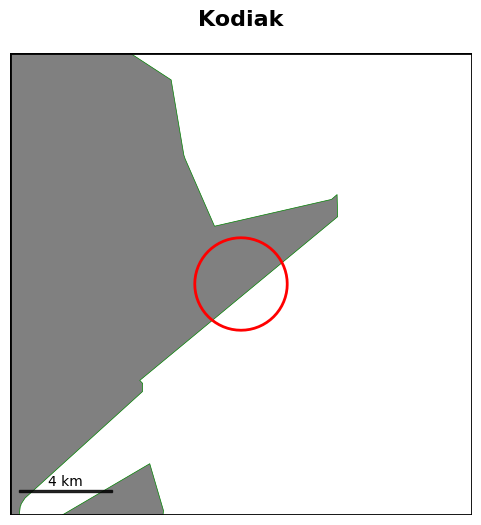

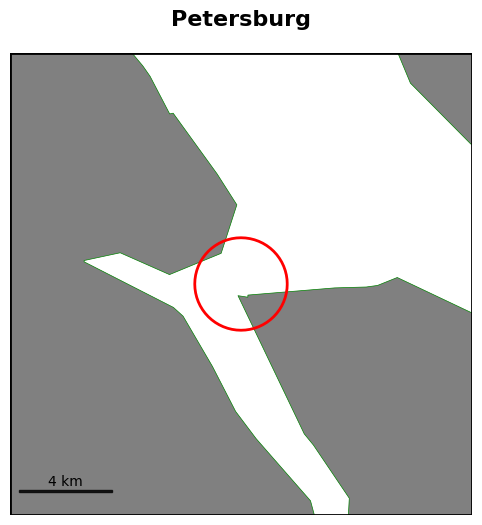

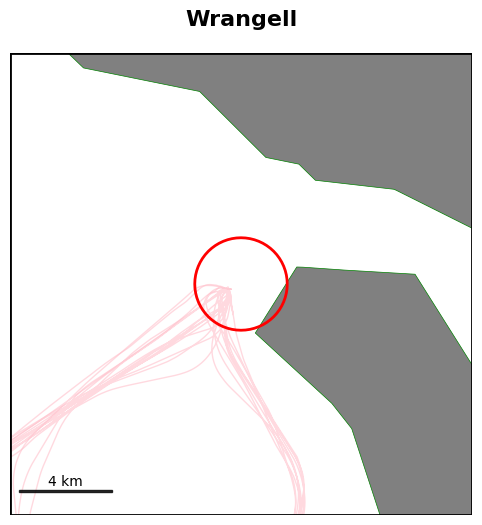

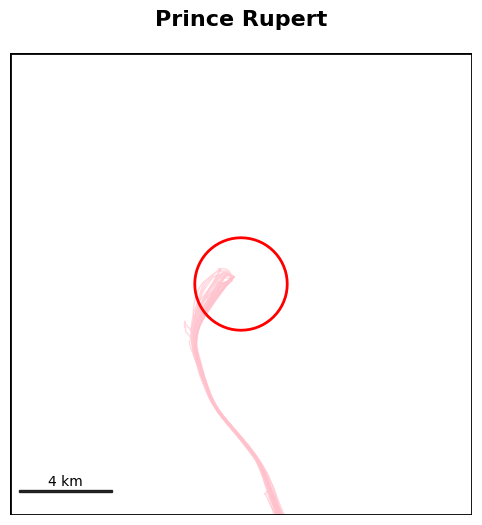

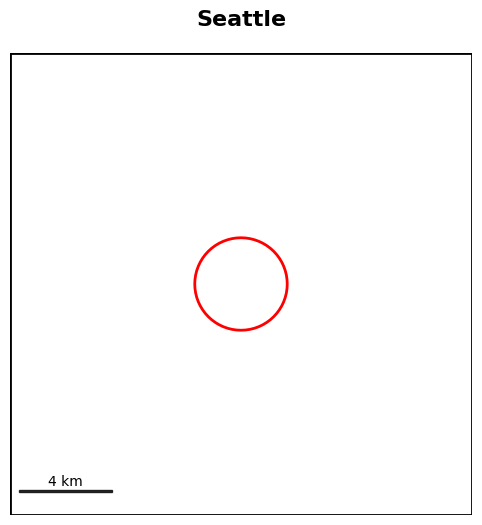

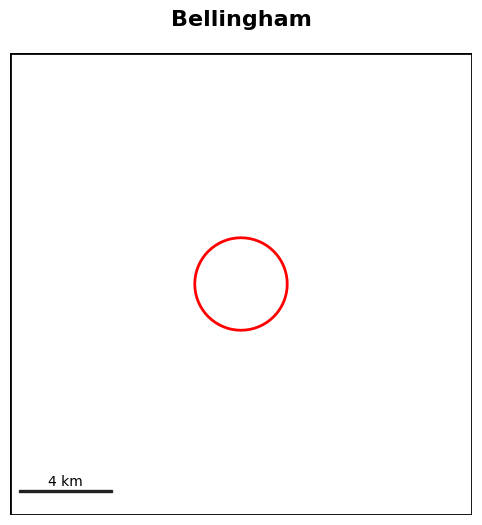

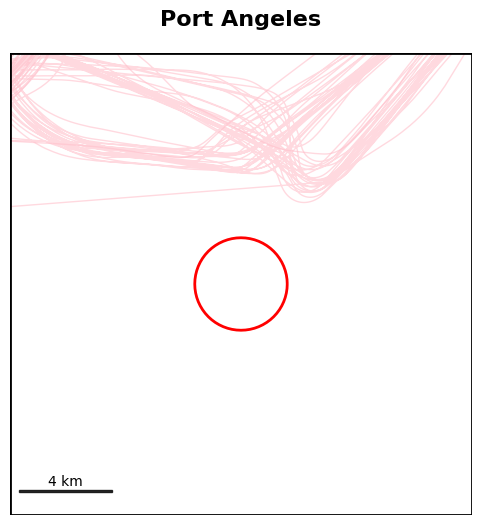

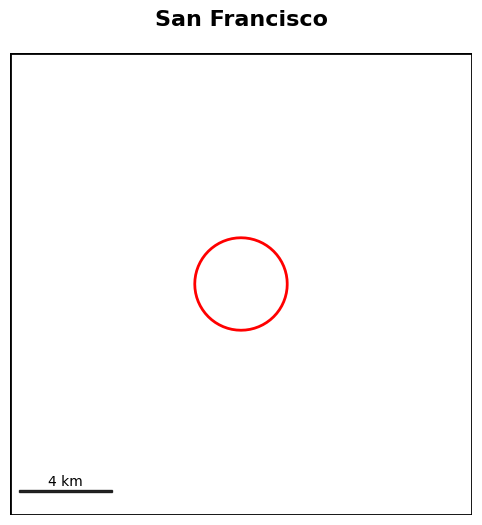

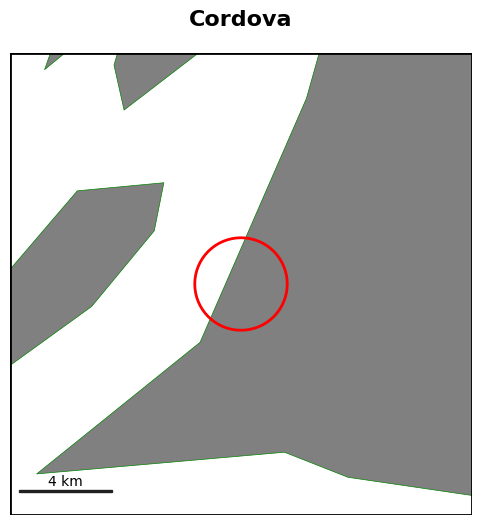

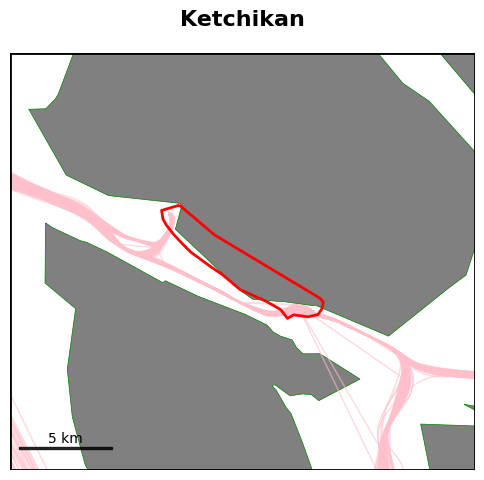

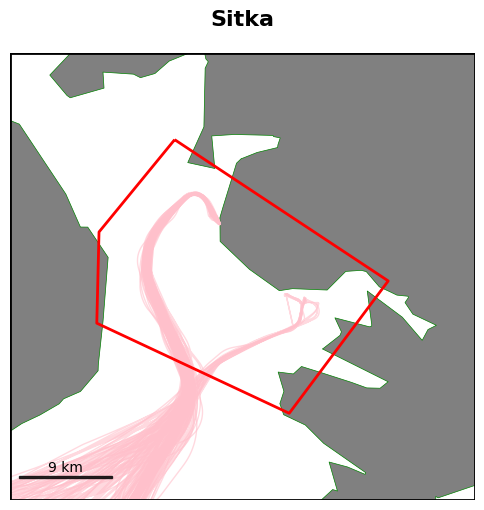

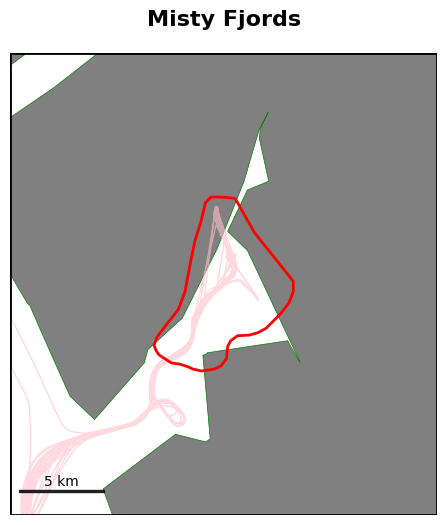

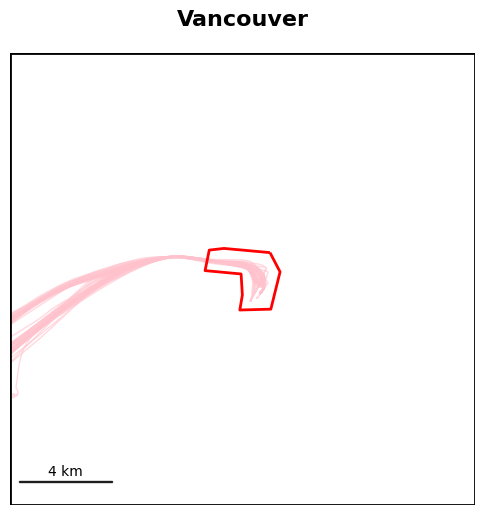

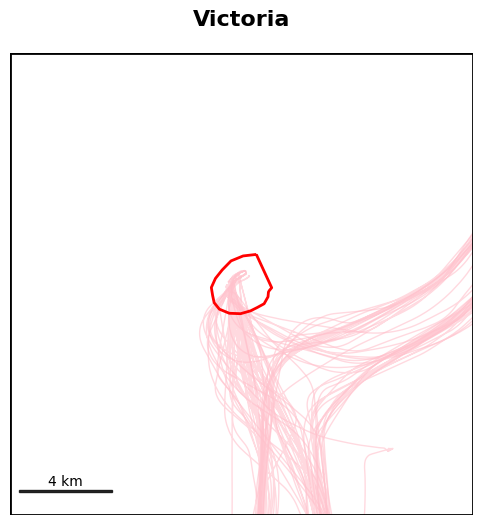

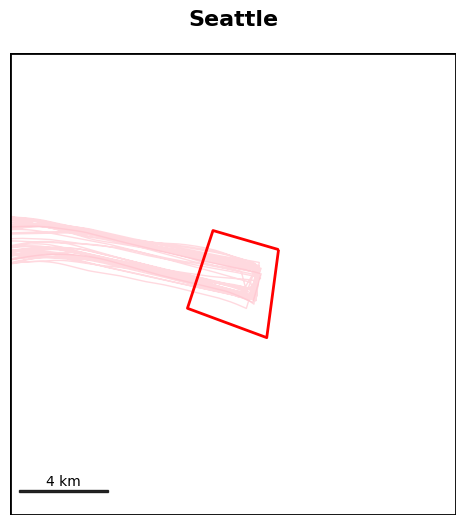

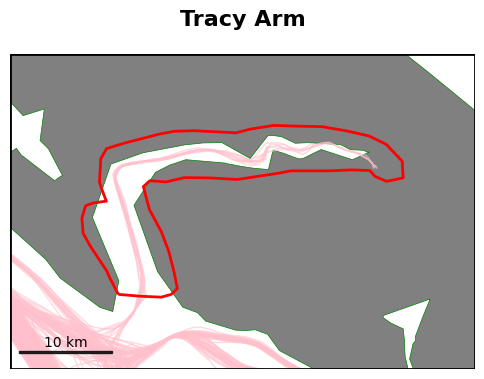

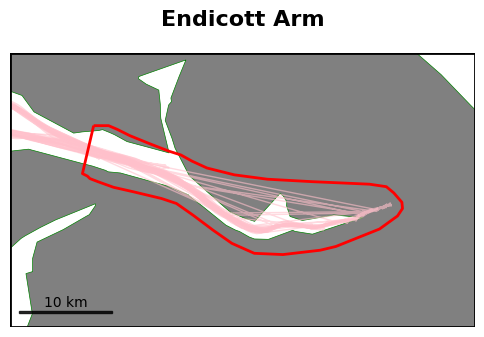

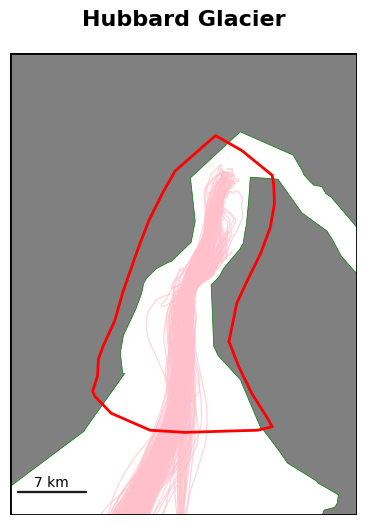

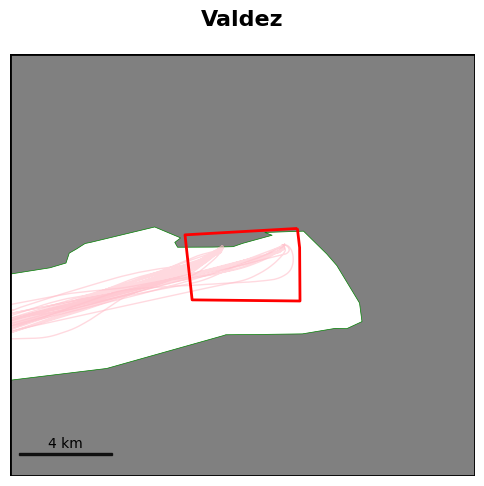

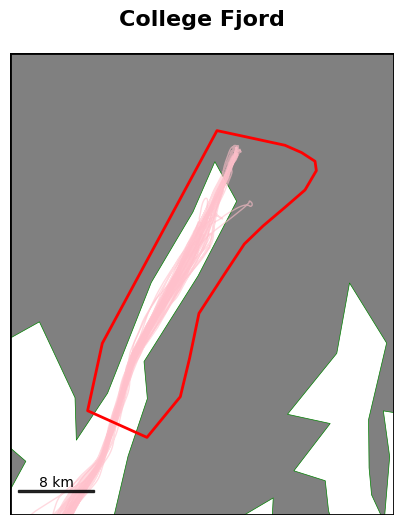

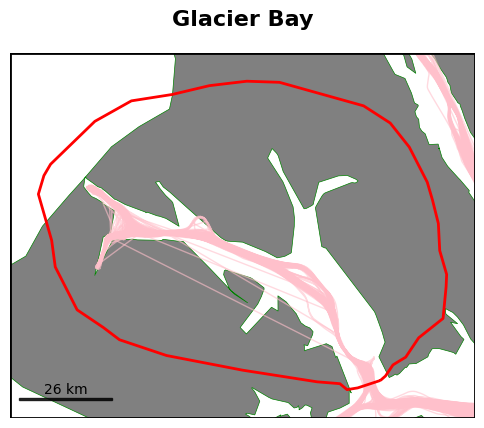

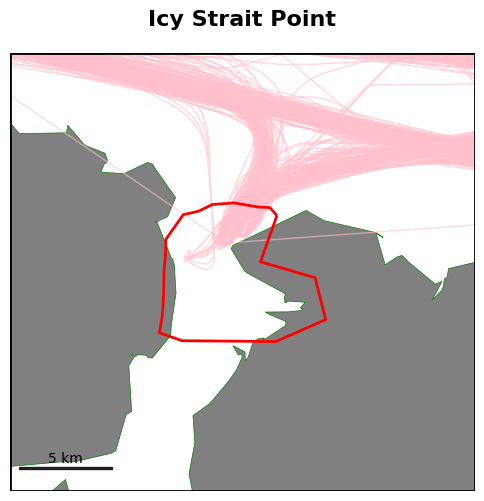

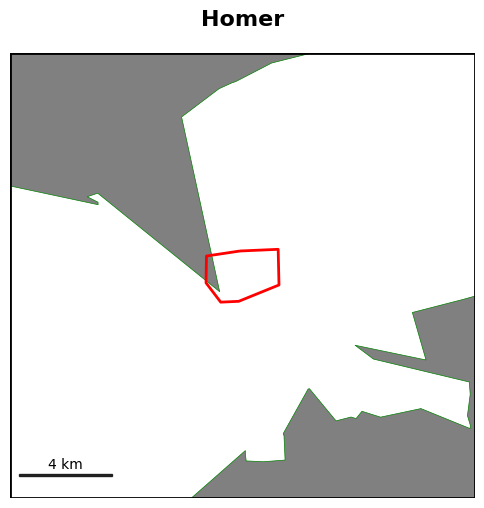

Maps saved successfully!


In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import contextily as ctx
from shapely.geometry import box
from BoatsData import *

for idx, feature in dock.iterrows():
    #print(feature)
    #print(dock.crs)
    buffered_geometry = feature.geometry.buffer(8000)
    buffered_gdf = gpd.GeoDataFrame(geometry=[buffered_geometry], crs=dock.crs)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_facecolor('darkblue')
    
    alaska.plot(ax=ax, color='grey', edgecolor="green", linewidth=0.5)
    track.plot(ax=ax, edgecolor="pink", linewidth=1, alpha=0.6)
    dock[dock.index == idx].boundary.plot(ax=ax, edgecolor="red", facecolor='none', linewidth=2)


    ax.set_xlim(buffered_gdf.bounds.minx[0], buffered_gdf.bounds.maxx[0])
    ax.set_ylim(buffered_gdf.bounds.miny[0], buffered_gdf.bounds.maxy[0])
    ax.axis('off')

    title_text = feature['name']
    plt.title(title_text, fontsize=16, fontweight='bold', loc='center', pad=20)

    scale_length = (buffered_gdf.bounds.maxx[0] - buffered_gdf.bounds.minx[0]) / 5  # 1/5 of width as scale bar length
    scale_x = buffered_gdf.bounds.minx[0] + scale_length * 0.1  
    scale_y = buffered_gdf.bounds.miny[0] + (buffered_gdf.bounds.maxy[0] - buffered_gdf.bounds.miny[0]) * 0.05  # 5% from bottom

    scale_bar = Rectangle((scale_x, scale_y), scale_length, scale_length / 50, color="black", alpha=0.8, zorder=4)
    ax.add_patch(scale_bar)
    ax.text(scale_x + scale_length / 2, scale_y + scale_length / 25, f"{scale_length/1000:.0f} km", 
            ha='center', va='bottom', fontsize=10, color='black', zorder=5)
    
    bbox = Rectangle((buffered_gdf.bounds.minx[0], buffered_gdf.bounds.miny[0]), 
                     buffered_gdf.bounds.maxx[0] - buffered_gdf.bounds.minx[0],
                     buffered_gdf.bounds.maxy[0] - buffered_gdf.bounds.miny[0],
                     linewidth=2, edgecolor='black', facecolor='none', zorder=6)
    ax.add_patch(bbox)

    output_path = os.path.join(r'./maps/docks', f"{title_text}_dock.png")
    plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()

    plt.close(fig)

print("Maps saved successfully!")


#### **Section 5** Prove the behind-the-scenes calculations of distances along paths produce accurate results.


Check in github to view this code in `PathCalculations.py`

Originally developed using deprecated geopy.distance.geodesic, this code was revised to use geopy.distance.distance, producing the exact same results as wehn using the deprecated method.

#####  Logic for custom `distanceAlongPath_nm`

- The two points are assigned for each pair to point1 and point2.
- Their geodesic distance is calculated using the built-in function
- These meter values are converted to nautical miles
- The summation of the incremental distances between each pair of points represents the **total distance traveled**

In [14]:
# Function that will be used to calculate incremental distances. Check contents in PathCalculations.py
import pandas as pd
from geopy.distance import geodesic
from geopy.distance import distance

from shapely.geometry import LineString
import geopandas as gpd

def distanceAlongPath_nm(geometry, start_index, end_index):
    """
    Returns a DataFrame with distances along the path that connects points in self.gdf between start and end indices, inclusive.
    Each row in the DataFrame represents a segment with start and end points, distance in nautical miles, 
    and cumulative distance in nautical miles.
    """
    distances = []
    cumulative_distance = 0
    
    for i in range(start_index, end_index):
        point1 = geometry.iloc[i] # Get start point
        point2 = geometry.iloc[i + 1] # get next point (end point)
        
        distance_nm = distance((point1.y, point1.x), (point2.y, point2.x)).meters / 1852 # gather dist in meters between two points, convert to nautical miles
        cumulative_distance += distance_nm
        
        distances.append({
            'index': i,
            'start_point': (point1.x, point1.y),
            'end_point': (point2.x, point2.y),
            'distance_nm': round(distance_nm, 2),
            'cumulative_distance_nm': round(cumulative_distance, 2)
        })
    
    distances_df = pd.DataFrame(distances)
    return distances_df


How many AIS data points fall within Glacier Bay shapefile boundary?

In [12]:
within_glba = a.data_dict['2023_ais']['ais_data']['within_glba']
len(within_glba)

76192

#### **Section 6**: Demonstrate the calculation directly.

In [15]:
data = a.data_dict['2023_ais']['ais_data']['within_glba']
assert data.segment_id.nunique() == 258
assert len(data[data.status != 'inPort']) == 0
# assert PortManager.DOCK_BUFFERS == check we have the proper geofence
data = a.data_dict['2023_ais']['ais_data']['within_glba'] # check these contested outputs
ports = pd.DataFrame(columns = ['segment_id', 'port', 'start_index', 'end_index',
                                        'port_duration', 'timelapse', 'time_in', 'time_out']) #create template for output data
port_data_list = []
segments = data.groupby('segment_id')
for segment_id, segment in segments:
    start_index = segment.index[0]
    end_index = segment.index[-1]
    time_in = segment.bs_ts.iloc[0]
    time_out = segment.bs_ts.iloc[-1]
    try:
        timelapse_to_next_port = PathCalculations.timelapseAlongPath(data.bs_ts, start_index, end_index)
    except IndexError:
        print(segment)
        print(f"Warning: end_index {end_index} is out of bounds. Assigning default values for timelapse.")
        timelapse_to_next_port = None

    try:
        _, distance_within_port = PathCalculations.distanceAlongPath_nm(data.geometry, start_index, end_index)
    except IndexError:
        print(segment)
        print(f"Warning: end_index {end_index} is out of bounds. Assigning default values for distance calculation.")
        distance_within_port = None    


    coords = [(point.x, point.y) for point in segment.geometry]

    line = LineString(coords)

    new_port = {'segment_id' : segment_id,
                'count_ais' : len(segment),
                'geometry' : line,
                'port' : segment.port.iloc[0],
                'start_index' : start_index,
                'end_index' : end_index,
                'distance_nm': round(distance_within_port, 3),
                'port_duration' : (time_out-time_in).total_seconds() / 3600,
                'timelapse' : timelapse_to_next_port,
                'time_in' : time_in,
                'time_out' : time_out,
                'imo' : segment.imo.iloc[0],
                'name' : segment.name.iloc[0]}
    port_data_list.append(new_port)

if len(port_data_list) > 0:
    ports = pd.concat([ports, gpd.GeoDataFrame(port_data_list)]).sort_values('segment_id').reset_index()

#ports
# Assuming your DataFrame is named df
# Calculate mean and standard deviation for the 'distance' field
mean_distance = round(ports['distance_nm'].mean(), 3)
std_distance = round(ports['distance_nm'].std(), 3)

# Calculate mean and standard deviation for the 'timelapse' field
mean_timelapse = round(ports['timelapse'].mean(), 3)
std_timelapse = round(ports['timelapse'].std() ,3)

# Output the results
print(f"Mean Distance: {mean_distance}, Standard Deviation: {std_distance}")
print(f"Mean Timelapse: {mean_timelapse}, Standard Deviation: {std_timelapse}")

assert ports.count_ais.sum() == 76192 # check all points were processed
#ports

Mean Distance: 117.604, Standard Deviation: 4.948
Mean Timelapse: 9.646, Standard Deviation: 0.717


Convert and save these results so we can display and compare within GIS

In [43]:
gdf = gpd.GeoDataFrame(ports, geometry='geometry') # ports is defined above.

# Set the CRS to WGS84 (latitude/longitude)
gdf.set_crs(epsg=4326, inplace=True)
gdf.to_file("./audit/glba_lines_stats.shp", driver="ESRI Shapefile")

,index,segment_id,port,start_index,end_index,port_duration,timelapse,time_in,time_out,count_ais,geometry,distance_nm,imo,name
0,0,CROWN_PRINCESS_0076,Glacier Bay,31068,31445,10.802222,10.802,2023-07-09 05:45:35-08:00,2023-07-09 16:33:43-08:00,378.0,"LINESTRING (-135.97833 58.38515, -135.97205 58...",122.18,9293399.0,CROWN PRINCESS
1,1,EURODAM_0004,Glacier Bay,5422,5699,9.213056,9.213,2023-05-02 06:18:47-08:00,2023-05-02 15:31:34-08:00,278.0,"LINESTRING (-135.96216 58.39484, -135.96253 58...",114.68,9378448.0,EURODAM
2,2,EURODAM_0014,Glacier Bay,5700,6028,9.716667,9.717,2023-05-09 06:17:11-08:00,2023-05-09 16:00:11-08:00,329.0,"LINESTRING (-135.95656 58.38452, -135.95539 58...",120.05,9378448.0,EURODAM
3,3,EURODAM_0024,Glacier Bay,6029,6363,9.445556,9.446,2023-05-16 06:17:59-08:00,2023-05-16 15:44:43-08:00,335.0,"LINESTRING (-135.95981 58.39116, -135.96261 58...",122.12,9378448.0,EURODAM
4,4,EURODAM_0034,Glacier Bay,6364,6651,9.600000,9.600,2023-05-23 06:16:15-08:00,2023-05-23 15:52:15-08:00,288.0,"LINESTRING (-135.95451 58.39571, -135.95404 58...",121.49,9378448.0,EURODAM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,253,VOLENDAM_0126,Glacier Bay,51741,52050,9.058056,9.058,2023-08-27 05:52:43-08:00,2023-08-27 14:56:12-08:00,310.0,"LINESTRING (-135.95726 58.39443, -135.95698 58...",119.16,9156515.0,VOLENDAM
254,254,VOLENDAM_0134,Glacier Bay,52051,52363,9.065556,9.066,2023-09-03 06:01:39-08:00,2023-09-03 15:05:35-08:00,313.0,"LINESTRING (-135.95637 58.38706, -135.95475 58...",120.79,9156515.0,VOLENDAM
255,255,VOLENDAM_0142,Glacier Bay,52364,52683,8.847500,8.848,2023-09-10 06:22:48-08:00,2023-09-10 15:13:39-08:00,320.0,"LINESTRING (-135.95838 58.39589, -135.95825 58...",120.21,9156515.0,VOLENDAM
256,256,VOLENDAM_0150,Glacier Bay,52684,53008,8.861389,8.861,2023-09-17 06:29:00-08:00,2023-09-17 15:20:41-08:00,325.0,"LINESTRING (-135.95554 58.38491, -135.95477 58...",114.08,9156515.0,VOLENDAM


#### **Section 7**: In GIS, we can carry out the same calculation.

In [ ]:
#export some data to work with
a.data_dict['2023_ais']['ais_data']['within_glba'].to_file("./audit/within_glba__ais_points.shp", driver='ESRI Shapefile')

**Stages**
- Import data points
- Select by location intersecting the GLBA boundary
- String the points into lines by vessel/'segment'
- Calculate length of each line
- Convert units
- Calculate statistics

1. AIS Data Points and make selection

<img src="audit/figures/all_ais_points.png" alt="table" width="750"/>

2. Clip Points

<img src="audit/figures/ClipAndSEAlaska.png" alt="table" width="750"/>

3. Create Linestrings

<img src="audit/figures/linestrings.png" alt="table" width="750"/>

4. Display Table Calculations and Verify

<img src="audit/figures/table.png" alt="table" width="250"/>

Looks like we had 4 vessels whose distanced transited in GLBA rounded to 3 decimals were equivalent. But to double check, how many total vessels entered?

In [17]:
qgis_result = gpd.read_file(r'./audit/qgis_result_glba_lines.shp')
print(qgis_result.segment_id.nunique())

258


What is the mean?

In [19]:
print('mean is:', str(qgis_result.len_nm.mean()) + ' nm')
# The result is only off by several hundreths of a nautical mile.

mean is: 117.61459302325581 nm


_____________